# Stochastic Dynamic Programming, Value Iteration, and Policy Iteration

In the previous notebooks, we studied deterministic optimal control.

The system evolution was assumed to be known:

$$
x_{k+1}=f(x_k,u_k).
$$

If the current state and control were known, the next state was determined exactly.

Real systems, however, often contain uncertainty.

For example:

- a vehicle may experience disturbances,
- a robot may not execute an action perfectly,
- the environment may evolve unpredictably,
- system dynamics may contain noise.

We therefore move from deterministic transitions to stochastic transitions.

The main progression of this notebook is:

$$
\boxed{
\text{Deterministic DP}
\rightarrow
\text{Stochastic DP}
\rightarrow
\text{Value Iteration}
\rightarrow
\text{Policy Iteration}
}
$$

We will use a small stochastic navigation problem to make the value function and policy directly observable.

## 1. From Deterministic to Stochastic Dynamic Programming

In deterministic Dynamic Programming, choosing action $a$ in state $s$ determines the next state:

$$
s'=f(s,a).
$$

The Bellman recursion can therefore be written as:

$$
V(s)=
\min_a
\left[
c(s,a)
+
V(f(s,a))
\right].
$$

In a stochastic system, the same action may lead to different next states.

The transition model is represented by:

$$
\boxed{
P(s'|s,a)
}
$$

which gives the probability of reaching next state $s'$ after taking action $a$ in state $s$.

Because the next state is uncertain, we consider the expected future cost:

$$
\boxed{
V(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V(s')
\right].
}
$$

The major change from deterministic DP is therefore:

$$
\boxed{
\text{future cost}
\rightarrow
\text{expected future cost}.
}
$$

## 2. Stochastic Grid-World

Consider a robot moving in a small grid.

The robot can choose one of four actions:

$$
\mathcal{A}=
\{
\text{up},
\text{down},
\text{left},
\text{right}
\}.
$$

The objective is to reach a goal cell while minimizing accumulated cost.

Unlike deterministic navigation, the commanded action is not always executed perfectly.

For example, when commanding:

$$
\text{right},
$$

the robot may:

- move right with probability $0.8$,
- move up with probability $0.1$,
- move down with probability $0.1$.

Thus the action specifies a probability distribution over possible next states rather than one guaranteed next state.

### State Space

Each free grid cell represents a state:

$$
s=(r,c),
$$

where $r$ and $c$ are the row and column indices.

Obstacle cells are excluded from the valid state space.

The goal is located at:

$$
s_{\text{goal}}=(3,3).
$$

The transition model is stochastic:

$$
P(s'|s,a).
$$

For an intended action:

$$
a,
$$

we assume:

$$
P(\text{intended direction})=0.8
$$

and:

$$
P(\text{each perpendicular direction})=0.1.
$$

If a movement would leave the grid or enter an obstacle, the robot remains in its current state.

In [1]:
import numpy as np

# Grid dimensions
ROWS = 4
COLS = 4

# Special cells
goal = (3, 3)

obstacles = {
    (1, 1),
    (2, 2)
}

# Available actions
actions = ["up", "down", "left", "right"]

# Direction vectors
direction = {
    "up":    (-1, 0),
    "down":  (1, 0),
    "left":  (0, -1),
    "right": (0, 1),
}

# Perpendicular outcomes for each intended action
side_actions = {
    "up":    ["left", "right"],
    "down":  ["left", "right"],
    "left":  ["up", "down"],
    "right": ["up", "down"],
}

states = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
    if (r, c) not in obstacles
]

print("Number of valid states:", len(states))
print(states)

Number of valid states: 14
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 2), (1, 3), (2, 0), (2, 1), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


In [2]:
def move(state, action):
    """Apply one deterministic movement outcome."""

    dr, dc = direction[action]

    next_state = (
        state[0] + dr,
        state[1] + dc
    )

    # Outside grid
    outside = (
        next_state[0] < 0
        or next_state[0] >= ROWS
        or next_state[1] < 0
        or next_state[1] >= COLS
    )

    # Collision with obstacle
    blocked = next_state in obstacles

    if outside or blocked:
        return state

    return next_state

In [3]:
def transitions(state, action):
    """
    Return possible:
        (probability, next_state)
    pairs.
    """

    if state == goal:
        return [(1.0, goal)]

    outcomes = [
        (0.8, action),
        (0.1, side_actions[action][0]),
        (0.1, side_actions[action][1]),
    ]

    result = []

    for probability, actual_action in outcomes:
        next_state = move(state, actual_action)

        result.append(
            (probability, next_state)
        )

    return result

In [4]:
state = (0, 1)
action = "right"

print("Current state:", state)
print("Commanded action:", action)

for probability, next_state in transitions(state, action):
    print(
        f"P = {probability:.1f} -> {next_state}"
    )

Current state: (0, 1)
Commanded action: right
P = 0.8 -> (0, 2)
P = 0.1 -> (0, 1)
P = 0.1 -> (0, 1)


### Stage Cost

We assign a cost for each movement:

$$
c(s,a)=1
$$

for every non-terminal state.

At the goal:

$$
c(s_{\text{goal}},a)=0.
$$

Therefore, minimizing cumulative cost encourages the robot to reach the goal using fewer expected steps.

Because transitions are stochastic, the optimal policy must consider both:

$$
\boxed{\text{path length}}
$$

and:

$$
\boxed{\text{transition uncertainty}.}
$$

## 3. Value Iteration

For our stochastic navigation problem, the Bellman optimality equation is:

$$
V^*(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^*(s')
\right].
$$

Here:

$$
V^*(s)
$$

is the optimal expected cost-to-go from state $s$.

However, unlike finite-horizon Dynamic Programming, we do not have a fixed terminal timestep from which to perform one backward recursion.

Instead, Value Iteration starts with an initial guess for the value function and repeatedly applies the Bellman update:

$$
\boxed{
V_{i+1}(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_i(s')
\right].
}
$$

The index $i$ represents the Value Iteration iteration, not a physical timestep.

The updates continue until the value function changes only by a very small amount.

### Action Value During a Bellman Update

For a particular state-action pair, define:

$$
Q(s,a)=
c(s,a)
+
\sum_{s'}
P(s'|s,a)V(s').
$$

This represents:

$$
\boxed{
\text{immediate cost}
+
\text{expected future cost}.
}
$$

The Bellman update selects the action with minimum expected cost:

$$
V_{\text{new}}(s)=
\min_a Q(s,a).
$$

Thus, Value Iteration repeatedly improves the estimate of the optimal cost-to-go for every state.

In [5]:
V = {
    state: 0.0
    for state in states
}

V[goal] = 0.0

In [6]:
def stage_cost(state, action):
    if state == goal:
        return 0.0

    return 1.0


def action_value(state, action, V):
    value = stage_cost(state, action)

    for probability, next_state in transitions(state, action):
        value += probability * V[next_state]

    return value

In [7]:
def bellman_update(V):

    V_new = V.copy()

    for state in states:

        if state == goal:
            V_new[state] = 0.0
            continue

        action_values = [
            action_value(state, action, V)
            for action in actions
        ]

        V_new[state] = min(action_values)

    return V_new

In [10]:
V = {
    state: 0.0
    for state in states
}

V[goal] = 0.0

In [18]:
V_new = bellman_update(V_new)

for state in states:
    print(state, ":", round(V_new[state], 3))
delta = max(
            abs(V_new[state] - V[state])
            for state in states
        )
delta


(0, 0) : 6.668
(0, 1) : 6.005
(0, 2) : 5.005
(0, 3) : 3.985
(1, 0) : 6.005
(1, 2) : 3.985
(1, 3) : 2.655
(2, 0) : 5.005
(2, 1) : 3.985
(2, 3) : 1.25
(3, 0) : 3.985
(3, 1) : 2.655
(3, 2) : 1.25
(3, 3) : 0.0


3.668224

### Convergence

After each Bellman update, we measure the largest change in any state value:

$$
\Delta=
\max_s
\left|
V_{\text{new}}(s)-V(s)
\right|.
$$

When:

$$
\Delta < \epsilon,
$$

the value function is considered converged.

The converged value approximates the optimal value function:

$$
V(s)\rightarrow V^*(s).
$$

In [19]:
def value_iteration(tolerance=1e-8, max_iterations=1000):

    V = {
        state: 0.0
        for state in states
    }

    history = []

    for iteration in range(max_iterations):

        V_new = bellman_update(V)

        delta = max(
            abs(V_new[state] - V[state])
            for state in states
        )
        
        history.append(delta)

        V = V_new

        if delta < tolerance:
            print(
                f"Converged after {iteration + 1} iterations"
            )
            break

    return V, history

In [20]:
V_opt, value_history = value_iteration()

print("\nOptimal values:")

for state in states:
    print(
        state,
        ":",
        round(V_opt[state], 3)
    )

Converged after 35 iterations

Optimal values:
(0, 0) : 7.535
(0, 1) : 6.424
(0, 2) : 5.174
(0, 3) : 4.062
(1, 0) : 6.424
(1, 2) : 4.062
(1, 3) : 2.674
(2, 0) : 5.174
(2, 1) : 4.062
(2, 3) : 1.25
(3, 0) : 4.062
(3, 1) : 2.674
(3, 2) : 1.25
(3, 3) : 0.0


## 4. Extracting the Optimal Policy

After Value Iteration converges, we have the optimal value function:

$$
V^*(s).
$$

For every state, we evaluate each possible action:

$$
Q(s,a)=
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^*(s').
$$

The optimal policy selects the action with minimum expected cost:

$$
\boxed{
\pi^*(s)=
\arg\min_a
Q(s,a)
}
$$

Therefore:

$$
\boxed{
V^*(s)
\rightarrow
\text{optimal expected cost-to-go}
}
$$

while:

$$
\boxed{
\pi^*(s)
\rightarrow
\text{optimal action}.
}
$$

In [21]:
def extract_policy(V):

    policy = {}

    for state in states:

        if state == goal:
            policy[state] = "goal"
            continue

        action_values = {
            action: action_value(state, action, V)
            for action in actions
        }

        best_action = min(
            action_values,
            key=action_values.get
        )

        policy[state] = best_action

    return policy


policy_opt = extract_policy(V_opt)

In [22]:
arrow = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→",
    "goal": "G"
}

for r in range(ROWS):

    row = []

    for c in range(COLS):

        state = (r, c)

        if state in obstacles:
            row.append("X")

        else:
            row.append(
                arrow[policy_opt[state]]
            )

    print(row)

['↓', '→', '→', '↓']
['↓', 'X', '→', '↓']
['↓', '↓', 'X', '↓']
['→', '→', '→', 'G']


In [23]:
V_grid = np.full(
    (ROWS, COLS),
    np.nan
)

for state in states:
    V_grid[state] = V_opt[state]

print(np.round(V_grid, 2))

[[7.53 6.42 5.17 4.06]
 [6.42  nan 4.06 2.67]
 [5.17 4.06  nan 1.25]
 [4.06 2.67 1.25 0.  ]]


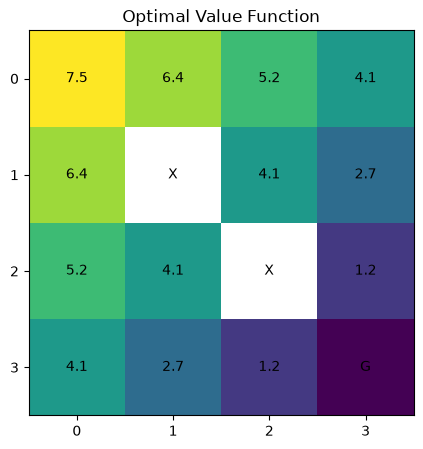

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(V_grid)

for r in range(ROWS):
    for c in range(COLS):

        state = (r, c)

        if state in obstacles:
            plt.text(
                c, r, "X",
                ha="center",
                va="center"
            )

        elif state == goal:
            plt.text(
                c, r, "G",
                ha="center",
                va="center"
            )

        else:
            plt.text(
                c, r,
                f"{V_opt[state]:.1f}",
                ha="center",
                va="center"
            )

plt.xticks(range(COLS))
plt.yticks(range(ROWS))
plt.title("Optimal Value Function")
plt.show()

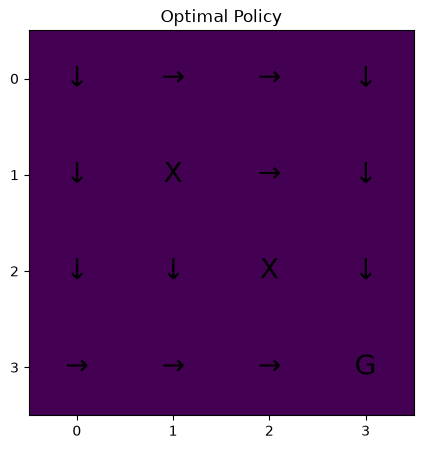

In [25]:
plt.figure(figsize=(6, 5))

plt.imshow(
    np.zeros((ROWS, COLS))
)

for r in range(ROWS):
    for c in range(COLS):

        state = (r, c)

        if state in obstacles:
            symbol = "X"

        elif state == goal:
            symbol = "G"

        else:
            symbol = arrow[
                policy_opt[state]
            ]

        plt.text(
            c, r,
            symbol,
            ha="center",
            va="center",
            fontsize=20
        )

plt.xticks(range(COLS))
plt.yticks(range(ROWS))
plt.title("Optimal Policy")
plt.show()

### Interpretation

Value Iteration gives us two related results.

The optimal value function:

$$
V^*(s)
$$

describes the minimum expected future cost from every state.

The optimal policy:

$$
\pi^*(s)
$$

describes the action that should be selected in every state.

Therefore:

$$
\boxed{
V^*
\rightarrow
\text{evaluate states}
}
$$

and:

$$
\boxed{
\pi^*
\rightarrow
\text{select actions}.
}
$$

The policy is obtained greedily with respect to the converged value function:

$$
\pi^*(s)=
\arg\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^*(s')
\right].
$$

## 5. Policy Iteration

Value Iteration repeatedly applies the Bellman optimality update:

$$
V_{i+1}(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_i(s')
\right].
$$

At every update, it immediately chooses the best action.

Policy Iteration separates this process into two steps:

$$
\boxed{
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}
}
$$

Starting from an initial policy:

$$
\pi(s),
$$

we repeatedly:

1. evaluate how good the current policy is,
2. improve the policy using the resulting value function.

The process continues until the policy no longer changes.

In [26]:
rng = np.random.default_rng(0)

policy = {}

for state in states:

    if state == goal:
        policy[state] = "goal"

    else:
        policy[state] = rng.choice(actions)

### Policy Evaluation

For a fixed policy:

$$
\pi(s),
$$

the action is already determined.

Therefore, the Bellman equation becomes:

$$
\boxed{
V^\pi(s)=
c(s,\pi(s))
+
\sum_{s'}
P(s'|s,\pi(s))
V^\pi(s').
}
$$

Unlike Value Iteration, there is no:

$$
\min_a
$$

during Policy Evaluation.

We repeatedly apply this update until the value function for the current policy converges.

The resulting:

$$
V^\pi(s)
$$

answers:

> What is the expected cost-to-go if we start from state $s$ and continue following policy $\pi$?

In [27]:
def policy_evaluation(
    policy,
    tolerance=1e-8,
    max_iterations=1000
):

    V = {
        state: 0.0
        for state in states
    }

    for iteration in range(max_iterations):

        V_new = V.copy()

        for state in states:

            if state == goal:
                V_new[state] = 0.0
                continue

            action = policy[state]

            V_new[state] = action_value(
                state,
                action,
                V
            )

        delta = max(
            abs(V_new[state] - V[state])
            for state in states
        )

        V = V_new

        if delta < tolerance:
            break

    return V

## 7. Policy Improvement

After evaluating the current policy, we obtain:

$$
V^\pi(s).
$$

We then evaluate every possible action using:

$$
Q^\pi(s,a)=
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^\pi(s').
$$

The policy is improved by selecting:

$$
\boxed{
\pi_{\text{new}}(s)=
\arg\min_a
Q^\pi(s,a).
}
$$

If:

$$
\pi_{\text{new}}(s)=
\pi(s)
$$

for every state, the policy is stable and the algorithm has converged.

In [28]:
def policy_improvement(V, policy):

    new_policy = policy.copy()
    policy_stable = True

    for state in states:

        if state == goal:
            continue

        old_action = policy[state]

        action_values = {
            action: action_value(
                state,
                action,
                V
            )
            for action in actions
        }

        best_action = min(
            action_values,
            key=action_values.get
        )

        new_policy[state] = best_action

        if best_action != old_action:
            policy_stable = False

    return new_policy, policy_stable

## 8. Complete Policy Iteration

Policy Iteration alternates between:

### Policy Evaluation

$$
\pi_i
\rightarrow
V^{\pi_i}
$$

and:

### Policy Improvement

$$
V^{\pi_i}
\rightarrow
\pi_{i+1}.
$$

Therefore:

$$
\boxed{
\pi_0
\rightarrow
V^{\pi_0}
\rightarrow
\pi_1
\rightarrow
V^{\pi_1}
\rightarrow
\cdots
\rightarrow
\pi^*.
}
$$

In [29]:
def policy_iteration(max_iterations=100):

    rng = np.random.default_rng(0)

    # Initial random policy
    policy = {}

    for state in states:

        if state == goal:
            policy[state] = "goal"

        else:
            policy[state] = rng.choice(actions)

    for iteration in range(max_iterations):

        # 1. Policy Evaluation
        V = policy_evaluation(policy)

        # 2. Policy Improvement
        new_policy, stable = policy_improvement(
            V,
            policy
        )

        print(
            f"Policy iteration {iteration + 1} | "
            f"stable = {stable}"
        )

        policy = new_policy

        if stable:
            print("Policy converged.")
            break

    # Evaluate final policy
    V = policy_evaluation(policy)

    return V, policy

In [30]:
V_pi, policy_pi = policy_iteration()

Policy iteration 1 | stable = False
Policy iteration 2 | stable = False
Policy iteration 3 | stable = False
Policy iteration 4 | stable = False
Policy iteration 5 | stable = True
Policy converged.


## 9. Value Iteration vs Policy Iteration

Value Iteration and Policy Iteration solve the same stochastic optimal-control problem.

They differ primarily in how the Bellman equations are used.

### Value Iteration

Value Iteration repeatedly applies the Bellman optimality update:

$$
V_{i+1}(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_i(s')
\right].
$$

Policy improvement is therefore implicit inside every value update.

### Policy Iteration

Policy Iteration explicitly separates:

$$
\boxed{
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}.
}
$$

For a fixed policy:

$$
V^\pi(s)=
c(s,\pi(s))
+
\sum_{s'}
P(s'|s,\pi(s))V^\pi(s').
$$

After evaluating the policy, it is improved using:

$$
\pi_{\text{new}}(s)=
\arg\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^\pi(s')
\right].
$$

Both methods should converge to the same optimal solution:

$$
V^*(s),\qquad \pi^*(s).
$$

In [31]:
print("State        Value Iteration     Policy Iteration")

for state in states:

    print(
        f"{str(state):12s}"
        f"{V_opt[state]:15.4f}"
        f"{V_pi[state]:20.4f}"
    )

State        Value Iteration     Policy Iteration
(0, 0)               7.5347              7.5347
(0, 1)               6.4236              6.4236
(0, 2)               5.1736              5.1736
(0, 3)               4.0625              4.0625
(1, 0)               6.4236              6.4236
(1, 2)               4.0625              4.0625
(1, 3)               2.6736              2.6736
(2, 0)               5.1736              5.1736
(2, 1)               4.0625              4.0625
(2, 3)               1.2500              1.2500
(3, 0)               4.0625              4.0625
(3, 1)               2.6736              2.6736
(3, 2)               1.2500              1.2500
(3, 3)               0.0000              0.0000


In [32]:
print("State        VI Policy     PI Policy")

for state in states:

    print(
        f"{str(state):12s}"
        f"{policy_opt[state]:14s}"
        f"{policy_pi[state]:14s}"
    )

State        VI Policy     PI Policy
(0, 0)      down          down          
(0, 1)      right         right         
(0, 2)      right         right         
(0, 3)      down          down          
(1, 0)      down          down          
(1, 2)      right         right         
(1, 3)      down          down          
(2, 0)      down          down          
(2, 1)      down          down          
(2, 3)      down          down          
(3, 0)      right         right         
(3, 1)      right         right         
(3, 2)      right         right         
(3, 3)      goal          goal          


### Computational Difference

The algorithms organize computation differently.

| Value Iteration | Policy Iteration |
|---|---|
| Start with a value estimate | Start with a policy |
| Evaluate all actions during each Bellman update | Evaluate the currently selected action during policy evaluation |
| Immediately take the best action | Keep the policy fixed until evaluation is complete |
| Repeat Bellman optimality updates | Alternate policy evaluation and improvement |
| Policy emerges from the value function | Policy is explicitly maintained |

Conceptually:

$$
\boxed{
\text{Value Iteration}
:
V
\rightarrow
V
\rightarrow
V
\rightarrow
V^*
\rightarrow
\pi^*
}
$$

while:

$$
\boxed{
\text{Policy Iteration}
:
\pi_0
\rightarrow
V^{\pi_0}
\rightarrow
\pi_1
\rightarrow
V^{\pi_1}
\rightarrow
\cdots
\rightarrow
\pi^*.
}
$$

## 10. Bellman Equations — The Bigger Picture

### Finite-Horizon Dynamic Programming

For a finite horizon:

$$
V_k(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_{k+1}(s')
\right].
$$

The value function depends on the timestep:

$$
V_k(s).
$$

The solution is obtained by working backward from the terminal timestep.

---

### Infinite-Horizon Policy Evaluation

For a fixed stationary policy:

$$
V^\pi(s)=
c(s,\pi(s))
+
\sum_{s'}
P(s'|s,\pi(s))V^\pi(s').
$$

There is no minimization because the policy already determines the action.

---

### Infinite-Horizon Optimality

The optimal value function satisfies:

$$
V^*(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^*(s')
\right].
$$

Value Iteration repeatedly applies this optimality equation until convergence.

## 11. From Dynamic Programming Toward Reinforcement Learning

In this notebook, the transition model is known:

$$
P(s'|s,a).
$$

The cost function is also known:

$$
c(s,a).
$$

Therefore, Value Iteration and Policy Iteration can explicitly compute expectations such as:

$$
\sum_{s'}
P(s'|s,a)V(s').
$$

This is a model-based planning setting.

In Reinforcement Learning, the transition model may be unknown.

Instead of being given:

$$
P(s'|s,a),
$$

an agent may have to interact with the environment and observe samples:

$$
(s,a,c,s').
$$

This creates the central transition:

$$
\boxed{
\text{known model + Bellman equations}
\rightarrow
\text{experience + Bellman equations}.
}
$$

## 12. Takeaway

This notebook introduced decision-making under stochastic transitions.

The main change from deterministic Dynamic Programming was:

$$
\boxed{
\text{future cost}
\rightarrow
\text{expected future cost}.
}
$$

The transition model:

$$
P(s'|s,a)
$$

describes uncertainty in the next state.

### Value Iteration

Value Iteration repeatedly applies the Bellman optimality update:

$$
V_{i+1}(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_i(s')
\right]
$$

until the value function converges.

The optimal policy is then extracted using:

$$
\pi^*(s)=
\arg\min_a Q(s,a).
$$

### Policy Iteration

Policy Iteration separates optimization into:

$$
\boxed{
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}.
}
$$

Policy Evaluation computes:

$$
V^\pi,
$$

while Policy Improvement produces a better policy using the resulting value function.

Both methods solve the same optimal decision-making problem but organize the computation differently.

Most importantly, both algorithms assume that the environment model:

$$
P(s'|s,a)
$$

is known.

This provides the conceptual bridge toward Reinforcement Learning, where the model may instead have to be learned or replaced by experience sampled from the environment.

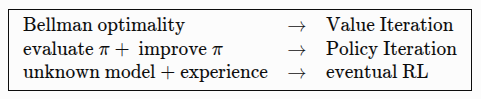

## 13. Notebook Summary

This notebook extended Dynamic Programming from deterministic systems to stochastic decision-making.

The key change was replacing a deterministic next state:

$$
s'=f(s,a)
$$

with a transition distribution:

$$
P(s'|s,a).
$$

Therefore, the Bellman recursion uses expected future cost:

$$
\boxed{
c(s,a)
+
\sum_{s'}
P(s'|s,a)V(s')
}
$$

### Value Iteration

Value Iteration repeatedly applies the Bellman optimality operator:

$$
V_{i+1}(s)=
\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V_i(s')
\right].
$$

After convergence, the optimal policy is extracted using:

$$
\pi^*(s)=
\arg\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^*(s')
\right].
$$

### Policy Iteration

Policy Iteration separates the problem into two operations:

$$
\boxed{
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}.
}
$$

Policy Evaluation determines the value of following the current policy:

$$
V^\pi(s)=
c(s,\pi(s))
+
\sum_{s'}
P(s'|s,\pi(s))V^\pi(s').
$$

Policy Improvement then chooses better actions:

$$
\pi_{\text{new}}(s)=
\arg\min_a
\left[
c(s,a)
+
\sum_{s'}
P(s'|s,a)V^\pi(s')
\right].
$$

Both Value Iteration and Policy Iteration converge toward the same optimal decision-making solution.

### Main Conceptual Progression

$$
\boxed{
\text{Deterministic DP}
\rightarrow
\text{Stochastic DP}
\rightarrow
\text{Value Iteration}
\rightarrow
\text{Policy Iteration}
}
$$

The central idea remains the Bellman principle:

$$
\boxed{
\text{current decision}
+
\text{cost-to-go}.
}
$$

The important new ingredient is uncertainty:

$$
\boxed{
\text{cost-to-go}
\rightarrow
\text{expected cost-to-go}.
}
$$

Finally, these methods assume that the transition model:

$$
P(s'|s,a)
$$

is known.

This will later provide an important connection to Reinforcement Learning, where decisions may need to be learned from sampled experience rather than computed from a known transition model.